# Restaurant Row FP and Behaviour: RRM003 and RRM004

## Behaviour Summary

_Goal_: plot various metrics for evaluating performance of mice in RR.
- Quantify statistics of different trial types, learning across sessions and how restaurant flavour preferences influence likelhood of choices

Create df with exp info: 
- session info: `animal ID`, `day`, `epoch`
- overview: `# of pellets/hour`, `median Inter Pellet Interval (IPI)`, `total time in RR`, `num of laps`
- learning: `no-reward dwell time`, `reject event count`, `reject accuracy`

### Condition Types

- `reject`: left turn, reject offer
- `quit`: right turn, quit before reward tone
- `rewarded`: right turn accept, reward offered and taken

In [1]:
#import packages

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os
import re
import matplotlib as mpl
from matplotlib import rc
from scipy import signal
from IPython.core.debugger import set_trace

#import behaviour functions
from main import *
from behaviour_functions.helper_functions import *
from behaviour_functions.plotting_functions import *

# import FP functions
from fp_functions.helper_functions import *
from fp_functions.plotting_fp import *

In [2]:
# load sessions for each mouse

# data paths - NOTE: change this to correct path based on computer using
fp_folder_RRMM003 = '/Volumes/Wilbrecht_file_server/LauraG/RR_FP_Data/RRM003'
behavior_folder_RRMM003 = '/Volumes/Wilbrecht_file_server/LauraG/RR_Behavior_Data/RRM003'

fp_folder_RRMM004 = '/Volumes/Wilbrecht_file_server/LauraG/RR_FP_Data/RRM004'
behavior_folder_RRMM004 = '/Volumes/Wilbrecht_file_server/LauraG/RR_Behavior_Data/RRM004'

# load behaviour data
bdata_RM0003 = load_behavior_FP(behavior_folder_RRMM003)
bdata_RM0004 = load_behavior_FP(behavior_folder_RRMM004)


In [3]:
%matplotlib inline

#Choose mouse to plot 
data = bdata_RM0003

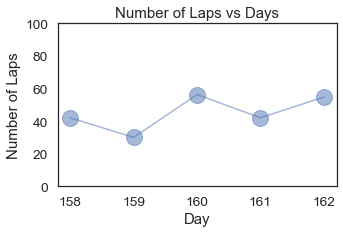

In [4]:
plot_laps(data)

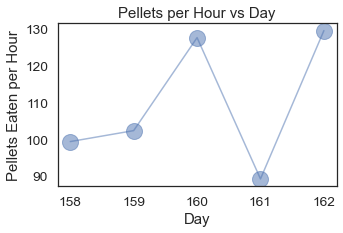

In [5]:
plot_pellets(data)

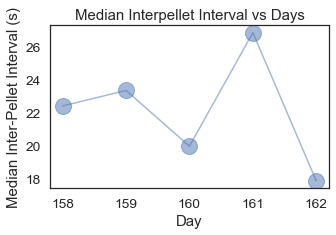

In [6]:
plot_iti(data)

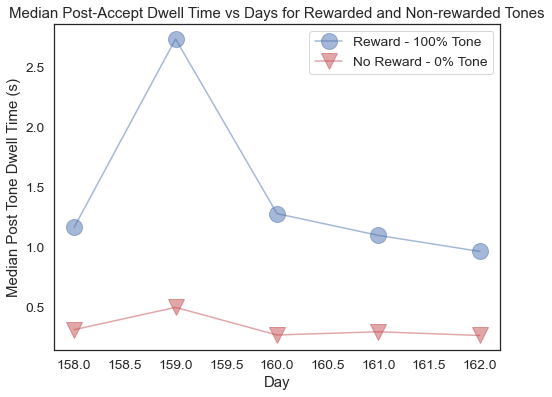

In [7]:
plot_dwell(data)

Rejection events per day: [36 24 66 37 78]


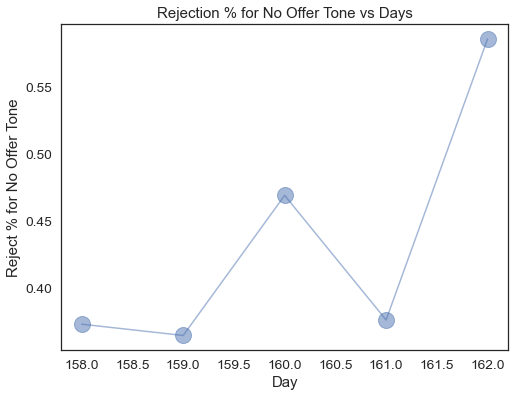

In [8]:
plot_rejections(data)

# FP Data

_Goal_: plot FP traces aligned to different event types for different outcome types (conditions)


### Condition Types

- `reject`: left turn, reject offer
- `quit`: right turn, quit before reward tone
- `rewarded`: right turn accept, reward offered and taken

### Alignment Types

- `offer_tone_x`: align to particular offer tone
- `entry`: align to sharp entry
- `accept`: align to sharp accept 
- `exit`: align to sharp exit 

### Plotting Function Parameters 
Note: for more information look at documentation for `grab_fp_traces` in fp_functions.helper_functions


_Parameters_:
- alignment: fp traces aligned to this time stamp
    - options -> 'offer_tone_0', 'entry', 'accept', 'exit'
        - if looking at condition = reject, can only align to entry or exit
        - note: aligning to 'offer_tone_0' will only keep 0 offer tone rejects, discard others
- channel: recording channel for FP
    - options -> 'green', 'red', 'control'
- side: hemisphere recording from
    - options -> 'left', 'right'
- condition: condition to plot
    - options -> 'rewarded', 'reject', 'quit'
- trigger_mode: triggering mode for neurophotometrics system
    - options -> 'TRIG1', 'TRIG3'
- split: split fp_traces into different sub-groups
    - options -> 'restaurant', 'offer_tone', 'none' for seperate plots
    - options --> 'all_restaurant', 'all_offer_tone' for overlayed plots
    
    

In [9]:
def offer_tone_aligned_fp_traces(channel, side, condition, data_fp, data_rr, trigger_mode, split):
    offer_tone_alignments = ['offer_tone_0','offer_tone_20', 'offer_tone_80', 'offer_tone_100']
    time_window = 99

    if split == 'none':
        signals_aligned = np.zeros([0, time_window*2])
    if split == 'restaurant':
        signals_aligned = {'R1':np.zeros([0, time_window*2]), 'R2':np.zeros([0, time_window*2]),
                        'R3': np.zeros([0, time_window*2]), 'R4': np.zeros([0, time_window*2])}
    if split == 'offer_tone':
        signals_aligned = {'offer_tone_0':[], 'offer_tone_20':[],
                        'offer_tone_80': [], 'offer_tone_100': []}

    for offer in offer_tone_alignments:
        signals_tone, t = grab_fp_traces(offer, channel, side, condition, data_fp, data_rr, trigger_mode, split)

        if split == 'none':
            signals_aligned = np.vstack([signals_aligned, signals_tone])

        if split == 'restaurant':
            rest = ['R1','R2', 'R3', 'R4']
            for rr in rest:
                signals_aligned[rr] = np.vstack([signals_aligned[rr], signals_tone[rr]])

        if split == 'offer_tone':
            signals_aligned[offer] = signals_tone[offer]
    return signals_aligned, t          
    

In [10]:
## Get Data RR
animal = 'RRM004'
day = 158
fp_folder = fp_folder_RRMM004
behavior_folder = behavior_folder_RRMM004

dt_choice, reject_events,accept_and_rewarded_events,num_accept_rewarded_events,quit_events, num_quit_events,pct_no_offer_rejects, dt_reject, dt_accept,data_rr, data_fp = get_data_rr(fp_folder, behavior_folder, animal, day)

/Volumes/Wilbrecht_file_server/LauraG/RR_FP_Data/RRM004/FP_Dayp158_epoch-5_ID-RRM004_2021-04-26T14_59_40.csv
Pellets Revealed R1: 25
Pellets Eaten R1: 25
Number of 0% Offer Tone Rejections: 8
Pellets Revealed R2: 23
Pellets Eaten R2: 22
Number of 0% Offer Tone Rejections: 15
Pellets Revealed R3: 15
Pellets Eaten R3: 15
Number of 0% Offer Tone Rejections: 27
Pellets Revealed R4: 19
Pellets Eaten R4: 17
Number of 0% Offer Tone Rejections: 27
Percentage of No Offer Rejections: 0.4426229508196721


In [23]:
# Load FP Trace to Compare
alignment = 'entry'
condition = 'rewarded'
channel = 'green'
side = 'left'
trigger_mode = 'TRIG1'
split = 'none'

signals_left, t_left = grab_fp_traces(alignment, channel, 'left', condition, data_fp, data_rr, trigger_mode, split)
signals_right, t_right = grab_fp_traces(alignment, channel, 'right', condition, data_fp, data_rr, trigger_mode, split)

signals_left, t_left = offer_tone_aligned_fp_traces(channel, 'left', condition, data_fp, data_rr, trigger_mode, split)
signals_right, t_right = offer_tone_aligned_fp_traces(channel, 'right', condition, data_fp, data_rr, trigger_mode, split)

Restaurant 1 has no traces for rewarded condition at probability tone 0
Restaurant 1 has no traces for rewarded condition at probability tone 20
Restaurant 1 has no traces for rewarded condition at probability tone 80
Restaurant 1 has no traces for rewarded condition at probability tone 100
Restaurant 2 has no traces for rewarded condition at probability tone 0
Restaurant 2 has no traces for rewarded condition at probability tone 20
Restaurant 2 has no traces for rewarded condition at probability tone 80
Restaurant 2 has no traces for rewarded condition at probability tone 100
Restaurant 3 has no traces for rewarded condition at probability tone 0
Restaurant 3 has no traces for rewarded condition at probability tone 20
Restaurant 3 has no traces for rewarded condition at probability tone 80
Restaurant 3 has no traces for rewarded condition at probability tone 100
Restaurant 4 has no traces for rewarded condition at probability tone 0
Restaurant 4 has no traces for rewarded condition at

(-0.5, 0.5)

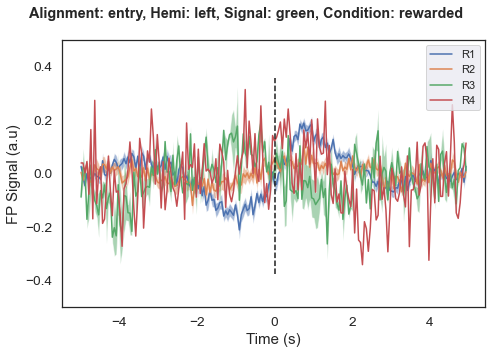

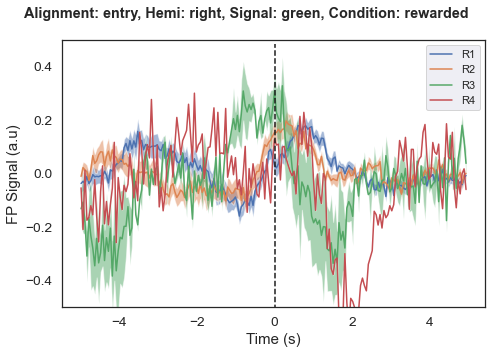

In [12]:
plot_opt = 'all_restaurant'
y_min=-0.5
y_max=0.5

plot_trial_avg_FP_aligned(signals_left, t_left, plot_opt, alignment, 'left', channel, condition)
plt.ylim(y_min,y_max)
plot_trial_avg_FP_aligned(signals_right, t_right, plot_opt, alignment, 'right', channel, condition)
plt.ylim(y_min,y_max)

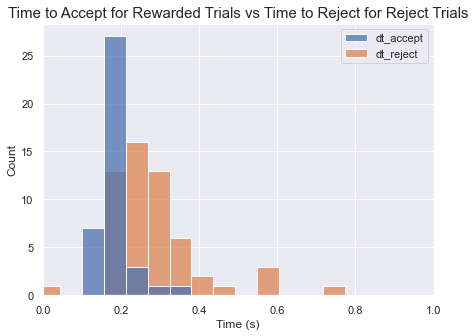

In [13]:
# Plot dt Histogram
plot_dt_hist(dt_choice)

In [14]:
## Previous Function
# signals_right, t_right, dt_choice = get_fp_traces(fp_folder_RRMM004, behavior_folder_RRMM004, 
#             mouse, day, alignment, channel, trigger_mode, 'right', condition, split)
# signals_left, t_left, dt_choice = get_fp_traces(fp_folder_RRMM003, behavior_folder_RRMM003, 
#             mouse, day, alignment, channel, trigger_mode, 'left', condition, split)

## Travis' Pipeline and Data

/Volumes/Wilbrecht_file_server/Restaurant Row/Data/fp_data/Cohort 3 D1/FP_Dayp130_epoch-8_ID-RRM001_2021-01-25T15_16_49.csv
Pellets Revealed R1: 7
Pellets Eaten R1: 7
Number of 0% Offer Tone Rejections: 3
Pellets Revealed R2: 13
Pellets Eaten R2: 13
Number of 0% Offer Tone Rejections: 3
Pellets Revealed R3: 17
Pellets Eaten R3: 17
Number of 0% Offer Tone Rejections: 3
Pellets Revealed R4: 17
Pellets Eaten R4: 17
Number of 0% Offer Tone Rejections: 3
num of rewarded events: 49, num of quit events:120
/Volumes/Wilbrecht_file_server/Restaurant Row/Data/fp_data/Cohort 3 D1/FP_Dayp130_epoch-8_ID-RRM001_2021-01-25T15_16_49.csv
Pellets Revealed R1: 7
Pellets Eaten R1: 7
Number of 0% Offer Tone Rejections: 3
Pellets Revealed R2: 13
Pellets Eaten R2: 13
Number of 0% Offer Tone Rejections: 3
Pellets Revealed R3: 17
Pellets Eaten R3: 17
Number of 0% Offer Tone Rejections: 3
Pellets Revealed R4: 17
Pellets Eaten R4: 17
Number of 0% Offer Tone Rejections: 3
num of rewarded events: 49, num of quit e

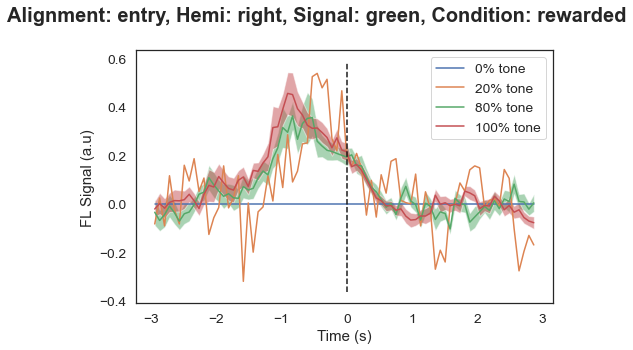

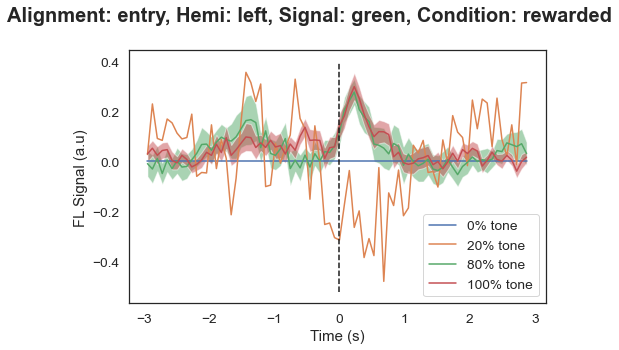

In [15]:
# Load Travis's Data 

get_fp_plots_travis('RRM001',130,'entry','green', 'right', 'rewarded',False, 'mean')
get_fp_plots_travis('RRM001',130,'entry','green', 'left', 'rewarded',False,'mean')

/Volumes/Wilbrecht_file_server/Restaurant Row/Data/fp_data/Cohort 3 D1/FP_Dayp130_epoch-8_ID-RRM001_2021-01-25T15_16_49.csv
Pellets Revealed R1: 7
Pellets Eaten R1: 7
Number of 0% Offer Tone Rejections: 3
Pellets Revealed R2: 13
Pellets Eaten R2: 13
Number of 0% Offer Tone Rejections: 3
Pellets Revealed R3: 17
Pellets Eaten R3: 17
Number of 0% Offer Tone Rejections: 3
Pellets Revealed R4: 17
Pellets Eaten R4: 17
Number of 0% Offer Tone Rejections: 3
num of rewarded events: 49, num of quit events:120
/Volumes/Wilbrecht_file_server/Restaurant Row/Data/fp_data/Cohort 3 D1/FP_Dayp130_epoch-8_ID-RRM001_2021-01-25T15_16_49.csv
Pellets Revealed R1: 7
Pellets Eaten R1: 7
Number of 0% Offer Tone Rejections: 3
Pellets Revealed R2: 13
Pellets Eaten R2: 13
Number of 0% Offer Tone Rejections: 3
Pellets Revealed R3: 17
Pellets Eaten R3: 17
Number of 0% Offer Tone Rejections: 3
Pellets Revealed R4: 17
Pellets Eaten R4: 17
Number of 0% Offer Tone Rejections: 3
num of rewarded events: 49, num of quit e

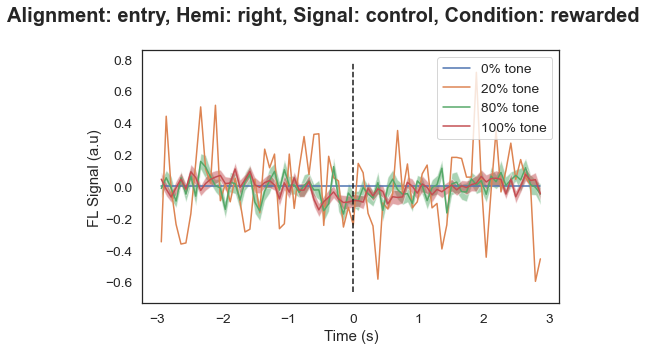

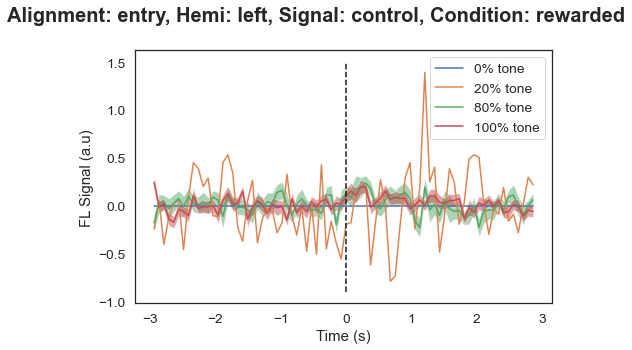

In [16]:

get_fp_plots_travis('RRM001',130,'entry','control', 'right', 'rewarded',False, 'mean')
get_fp_plots_travis('RRM001',130,'entry','control', 'left', 'rewarded',False,'mean')